In [10]:
import pandas as pd

In [11]:
df = pd.read_csv("C:/Datasets/breast-cancer-wisconsin.data")
df.head()

,id,clump_thickness,unif_cell_size,unif_cell_shape,marg_adhesion,single_epith_cell_size,bare_nulei,bland_chrom,norm_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [12]:
df.columns

Index(['id', ' clump_thickness', ' unif_cell_size', ' unif_cell_shape',
       ' marg_adhesion', ' single_epith_cell_size', ' bare_nulei',
       ' bland_chrom', ' norm_nucleoli', ' mitoses', ' class'],
      dtype='object')

In [13]:
df.columns = df.columns.str.replace(" ", "")
df.columns

Index(['id', 'clump_thickness', 'unif_cell_size', 'unif_cell_shape',
       'marg_adhesion', 'single_epith_cell_size', 'bare_nulei', 'bland_chrom',
       'norm_nucleoli', 'mitoses', 'class'],
      dtype='object')

In [14]:
df[df["bare_nulei"] == "?"]

,id,clump_thickness,unif_cell_size,unif_cell_shape,marg_adhesion,single_epith_cell_size,bare_nulei,bland_chrom,norm_nucleoli,mitoses,class
23,1057013,8,4,5,1,2,?,7,3,1,4
40,1096800,6,6,6,9,6,?,7,8,1,2
139,1183246,1,1,1,1,1,?,2,1,1,2
145,1184840,1,1,3,1,2,?,2,1,1,2
158,1193683,1,1,2,1,3,?,1,1,1,2
164,1197510,5,1,1,1,2,?,3,1,1,2
235,1241232,3,1,4,1,2,?,3,1,1,2
249,169356,3,1,1,1,2,?,3,1,1,2
275,432809,3,1,3,1,2,?,2,1,1,2
292,563649,8,8,8,1,2,?,6,10,1,4


In [15]:
df = df[df["bare_nulei"] != "?"]

In [16]:
df.drop(["id"], axis = 1, inplace = True)
df

,clump_thickness,unif_cell_size,unif_cell_shape,marg_adhesion,single_epith_cell_size,bare_nulei,bland_chrom,norm_nucleoli,mitoses,class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2,1,1,1,2
695,2,1,1,1,2,1,1,1,1,2
696,5,10,10,3,7,3,8,10,2,4
697,4,8,6,4,3,4,10,6,1,4


In [17]:
x = df.iloc[:, :9]
x

,clump_thickness,unif_cell_size,unif_cell_shape,marg_adhesion,single_epith_cell_size,bare_nulei,bland_chrom,norm_nucleoli,mitoses
0,5,1,1,1,2,1,3,1,1
1,5,4,4,5,7,10,3,2,1
2,3,1,1,1,2,2,3,1,1
3,6,8,8,1,3,4,3,7,1
4,4,1,1,3,2,1,3,1,1
...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2,1,1,1
695,2,1,1,1,2,1,1,1,1
696,5,10,10,3,7,3,8,10,2
697,4,8,6,4,3,4,10,6,1


In [18]:
y = df.iloc[:, 9]
y

0      2
1      2
2      2
3      2
4      2
      ..
694    2
695    2
696    4
697    4
698    4
Name: class, Length: 683, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [20]:
import math
k = math.sqrt(len(y_test))
k

11.704699910719626

In [22]:
if k % 2 == 0:
    k += 1
k = int(k)
k

11

In [23]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
model = KNeighborsClassifier(n_neighbors = k)
model.fit(x_train, y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
accuracy = model.score(x_test, y_test)

In [29]:
k_range = range(1, 16)
scores = []
for k in k_range:
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(x_train, y_train)
    accuracy = model.score(x_test, y_test)
    scores.append(accuracy)
    print(scores)

[0.9708029197080292]
[0.9708029197080292, 0.948905109489051]
[0.9708029197080292, 0.948905109489051, 0.9708029197080292]
[0.9708029197080292, 0.948905109489051, 0.9708029197080292, 0.9708029197080292]
[0.9708029197080292, 0.948905109489051, 0.9708029197080292, 0.9708029197080292, 0.9708029197080292]
[0.9708029197080292, 0.948905109489051, 0.9708029197080292, 0.9708029197080292, 0.9708029197080292, 0.9562043795620438]
[0.9708029197080292, 0.948905109489051, 0.9708029197080292, 0.9708029197080292, 0.9708029197080292, 0.9562043795620438, 0.9708029197080292]
[0.9708029197080292, 0.948905109489051, 0.9708029197080292, 0.9708029197080292, 0.9708029197080292, 0.9562043795620438, 0.9708029197080292, 0.9635036496350365]
[0.9708029197080292, 0.948905109489051, 0.9708029197080292, 0.9708029197080292, 0.9708029197080292, 0.9562043795620438, 0.9708029197080292, 0.9635036496350365, 0.9635036496350365]
[0.9708029197080292, 0.948905109489051, 0.9708029197080292, 0.9708029197080292, 0.9708029197080292,

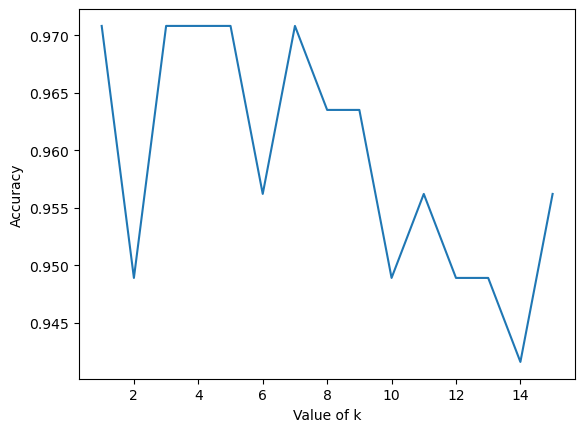

In [31]:
import matplotlib.pyplot as plt
plt.plot(k_range, scores)
plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.show()

In [32]:
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(x_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
accuracy = model.score(x_test, y_test)
accuracy

0.9708029197080292

In [35]:
model.predict([[4, 2, 1, 1, 1, 2, 3, 2, 1]])

c:\Users\MOHIT SINGH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([2])

In [36]:
model.predict([[4, 2, 1, 1, 1, 2, 3, 2, 1], [8, 10, 10, 8, 7, 10, 9, 7, 1]])

c:\Users\MOHIT SINGH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([2, 4])